#EDA

In [ ]:
# Install reqirements
!pip install kagglehub[pandas-datasets]

In [ ]:
# Import libraries
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the CSV file inside the dataset
file_path = "Lead Scoring.csv"

# Load the dataset into a pandas DataFrame
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "amritachatterjee09/lead-scoring-dataset",
    file_path,
)

# --- BASIC INFO ---
print("📊 Dataset shape:")
print(df.shape)

print("\n🧾 Dataset info:")
df.info()

# --- MISSING VALUES ---
print("\n❗ Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# --- DESCRIPTIVE STATS ---
print("\n📈 Numerical summary:")
print(df.describe())

# --- TARGET VARIABLE ---
print("\n🎯 Target distribution (Converted):")
print(df["Converted"].value_counts())

print("\n🎯 Target distribution (%):")
print(df["Converted"].value_counts(normalize=True))

/tmp/ipykernel_1342/1319011219.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'lead-scoring-dataset' dataset.
📊 Dataset shape:
(9240, 37)

🧾 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Ti

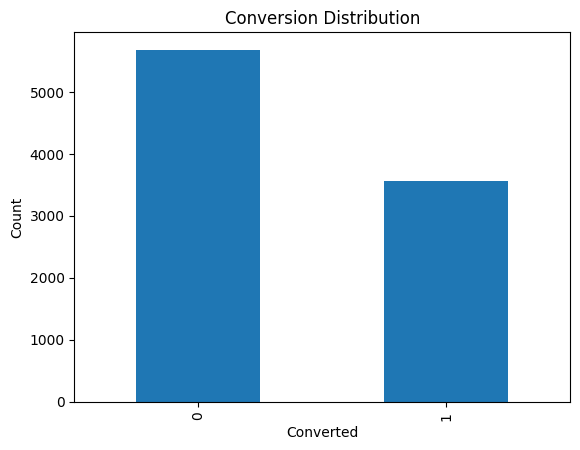

In [ ]:
# Import libraries
import matplotlib.pyplot as plt

# Conversion distribution
df["Converted"].value_counts().plot(kind="bar")
plt.title("Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Count")
plt.show()

In [ ]:
# Feature Engineering

# Engagement intensity feature
df["EngagementScore"] = (
    df["TotalVisits"] * df["Page Views Per Visit"]
)

# Average time spent per visit
df["TimePerVisit"] = (
    df["Total Time Spent on Website"] / (df["TotalVisits"] + 1)
)

# Preview the new features
print(df[[
    "TotalVisits",
    "Page Views Per Visit",
    "Total Time Spent on Website",
    "EngagementScore",
    "TimePerVisit"
]].head())

   TotalVisits  Page Views Per Visit  Total Time Spent on Website  \
0          0.0                   0.0                            0   
1          5.0                   2.5                          674   
2          2.0                   2.0                         1532   
3          1.0                   1.0                          305   
4          2.0                   1.0                         1428   

   EngagementScore  TimePerVisit  
0              0.0      0.000000  
1             12.5    112.333333  
2              4.0    510.666667  
3              1.0    152.500000  
4              2.0    476.000000  


In [ ]:

# Import libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

# Features for clustering
cluster_features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit",
    "EngagementScore",
    "TimePerVisit"
]


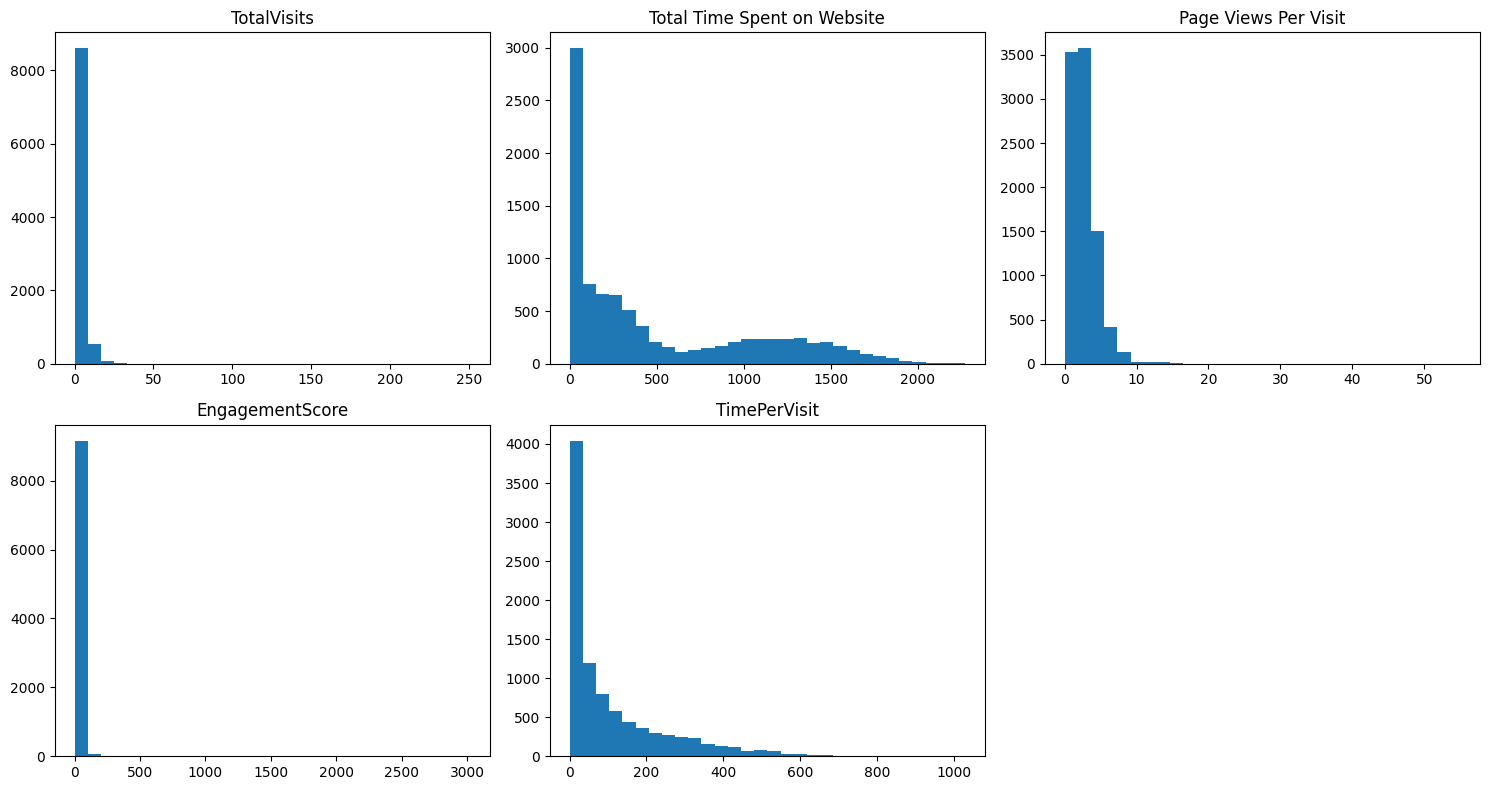

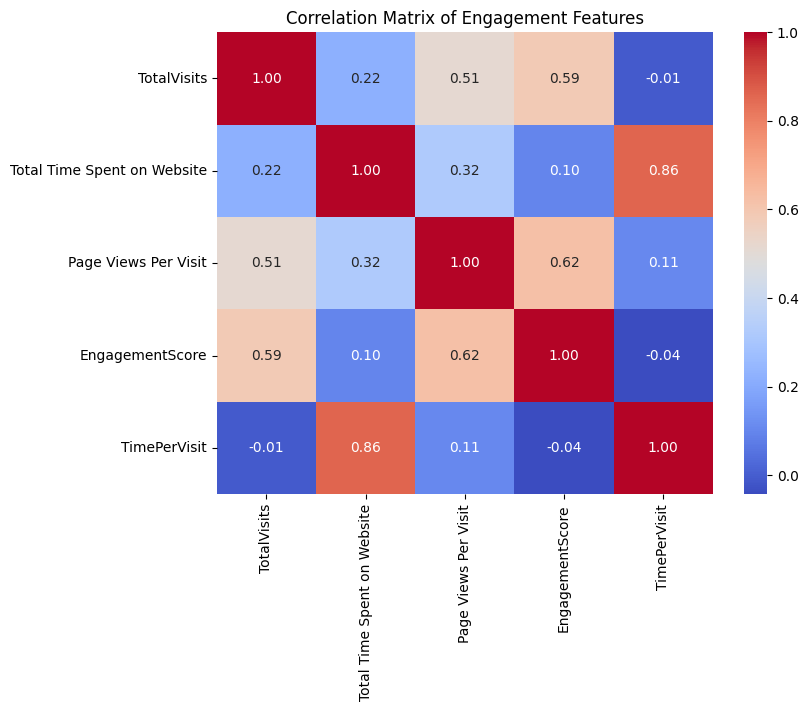

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit",
    "EngagementScore",
    "TimePerVisit"
]

# 1. Histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].fillna(0), bins=30)
    axes[i].set_title(col)

# Remove empty subplot (since 5 features in a 2x3 grid)
axes[-1].axis("off")

plt.tight_layout()
plt.show()

# 2. Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Engagement Features")
plt.show()

#Clustering

In [ ]:
# Create clustering dataset
X = df[cluster_features].copy()


# Handle missing values
X = X.fillna(0)


# Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_features
)

# Peview data
print("Scaled clustering dataset:")
print(X_scaled.head())

print("\nDataset shape:")
print(X_scaled.shape)

Scaled clustering dataset:
   TotalVisits  Total Time Spent on Website  Page Views Per Visit  \
0    -0.701791                    -0.889974             -1.075617   
1     0.332032                     0.339972              0.079576   
2    -0.288262                     1.905689             -0.151463   
3    -0.495026                    -0.333396             -0.613540   
4    -0.288262                     1.715905             -0.613540   

   EngagementScore  TimePerVisit  
0        -0.317497     -0.766974  
1        -0.019399      0.032809  
2        -0.222106      2.868835  
3        -0.293649      0.318785  
4        -0.269801      2.622018  

Dataset shape:
(9240, 5)


#Prediction

In [ ]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# select features
df = df[[
    "TotalVisits",
    "Total Time Spent on Website",
    "Page Views Per Visit",
    "Asymmetrique Activity Score",
    "Asymmetrique Profile Score",
    "Converted"
]]

# clean data
df = df.dropna()

# split
X = df.drop("Converted", axis=1)
y = df["Converted"]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("Model accuracy:", accuracy)

Model accuracy: 0.7325227963525835


In [ ]:
sample = [[5, 300, 3, 10, 12]]

prediction = model.predict(sample)
probability = model.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", probability)